# Medical VQA — InstructBLIP Open-Ended Captioning

InstructBLIP improves over BLIP-2 by connecting the same vision encoder
to a language model fine-tuned specifically on instruction-following data.
This makes it significantly better at answering specific questions about images
rather than generating generic descriptions.

**Model options (auto-selected based on available VRAM):**
- `Salesforce/instructblip-vicuna-7b` — 7B params, needs ~14GB VRAM (local PC)
- `Salesforce/instructblip-flan-t5-xl` — 4B params, needs ~9GB VRAM (Colab T4)

**Why InstructBLIP over BLIP-2:**
- BLIP-2 generates generic image descriptions
- InstructBLIP was fine-tuned on 13 instruction-tuning datasets
- Better at following specific question prompts
- More precise and specific outputs for medical VQA

## 1. Install Dependencies

In [ ]:
!pip install -q datasets transformers torch torchvision pillow evaluate rouge_score accelerate

## 2. Environment Detection and VRAM Check

In [2]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
from datasets import load_dataset
from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
import evaluate

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# --- Environment and VRAM detection ---
IS_COLAB = 'google.colab' in str(globals())
print('Environment:', 'Google Colab' if IS_COLAB else 'Local PC')

if torch.cuda.is_available():
    gpu_name  = torch.cuda.get_device_name(0)
    vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'GPU: {gpu_name}')
    print(f'VRAM: {vram_gb:.1f} GB')

    # Auto-select model based on VRAM
    if vram_gb >= 15:
        MODEL_NAME = 'Salesforce/instructblip-vicuna-7b'
        print('Selected model: instructblip-vicuna-7b (7B params, best quality)')
    else:
        MODEL_NAME = 'Salesforce/instructblip-flan-t5-xl'
        print('Selected model: instructblip-flan-t5-xl (4B params, fits Colab T4)')
else:
    MODEL_NAME = 'Salesforce/instructblip-flan-t5-xl'
    print('No GPU detected — using smaller model')

print(f'\nModel to load: {MODEL_NAME}')

c:\Users\Micah\Documents\code\Medical_VQA_Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Environment: Google Colab
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 17.1 GB
Selected model: instructblip-vicuna-7b (7B params, best quality)

Model to load: Salesforce/instructblip-vicuna-7b


## 3. Colab Setup (skip if running locally)

In [ ]:
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = '/content/drive/MyDrive/Medical_VQA'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print('Colab drive mounted. Save directory:', SAVE_DIR)
else:
    SAVE_DIR = './results'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print('Local save directory:', SAVE_DIR)

ModuleNotFoundError: No module named 'google'

## 4. Utility Functions

In [4]:
def open_image_from_dataset_value(image_value):
    """Opens an image from different possible HuggingFace/pandas formats."""
    if isinstance(image_value, Image.Image):
        return image_value
    if isinstance(image_value, dict) and image_value.get('bytes') is not None:
        return Image.open(io.BytesIO(image_value['bytes']))
    if isinstance(image_value, dict) and image_value.get('path') is not None:
        return Image.open(image_value['path'])
    return None


def normalize_text(x):
    if x is None:
        return None
    return str(x).strip().lower()


def infer_question_type(answer):
    ans = normalize_text(answer)
    if ans in {'yes', 'no'}:
        return 'binary'
    return 'open_ended'


print('Utilities ready!')

Utilities ready!


## 5. Load Dataset and Filter ROCO Subset

In [5]:
dataset = load_dataset('robailleo/medical-vision-llm-dataset')

train_df = dataset['train'].to_pandas()
val_df   = dataset['validation'].to_pandas()

train_df['question_type'] = train_df['answer'].apply(infer_question_type)
val_df['question_type']   = val_df['answer'].apply(infer_question_type)

val_roco = val_df[val_df['question_type'] == 'open_ended'].reset_index(drop=True)

print('Open-ended val size:', len(val_roco))
print('\nSample question:', val_roco['question'].iloc[0])
print('Sample answer:  ', val_roco['answer'].iloc[0])

Open-ended val size: 769

Sample question: what imaging modality was used?
Sample answer:   x-ray


## 6. Load InstructBLIP Model

This will download ~14GB for vicuna-7b or ~8GB for flan-t5-xl on first run.
Subsequent runs use the local cache.

In [6]:
print(f'Loading InstructBLIP processor from {MODEL_NAME}...')
processor = InstructBlipProcessor.from_pretrained(MODEL_NAME)

print(f'Loading InstructBLIP model in float16...')
print('This may take a few minutes on first run...')

model = InstructBlipForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True,
)
model = model.to(device)
model.eval()

print('\nInstructBLIP loaded!')
print('Total params:', f"{sum(p.numel() for p in model.parameters()):,}")

if torch.cuda.is_available():
    used_vram = torch.cuda.memory_allocated() / 1e9
    free_vram = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
    print(f'VRAM used: {used_vram:.1f} GB')
    print(f'VRAM free: {free_vram:.1f} GB')

    if free_vram < 1.0:
        print('WARNING: Very low free VRAM — consider switching to flan-t5-xl model')

Loading InstructBLIP processor from Salesforce/instructblip-vicuna-7b...
Loading InstructBLIP model in float16...
This may take a few minutes on first run...


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]c:\Users\Micah\Documents\code\Medical_VQA_Classification\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Micah\.cache\huggingface\hub\models--Salesforce--instructblip-vicuna-7b. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 


InstructBLIP loaded!
Total params: 7,913,726,720
VRAM used: 15.9 GB
VRAM free: 1.2 GB


In [11]:
torch.cuda.empty_cache()
free = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9
print(f'Free VRAM: {free:.1f} GB')

Free VRAM: 1.2 GB


## 7. Evaluation Metrics

In [8]:
bleu  = evaluate.load('bleu')
rouge = evaluate.load('rouge')


def compute_captioning_metrics(predictions, references):
    filtered = [(p, r) for p, r in zip(predictions, references) if p.strip()]
    if not filtered:
        return {'bleu': 0.0, 'rouge1': 0.0, 'rouge2': 0.0, 'rougeL': 0.0}

    preds, refs = zip(*filtered)
    preds = list(preds)
    refs  = list(refs)

    bleu_refs   = [[r] for r in refs]
    bleu_score  = bleu.compute(predictions=preds, references=bleu_refs)
    rouge_score = rouge.compute(predictions=preds, references=refs)

    return {
        'bleu':   round(bleu_score['bleu'], 4),
        'rouge1': round(rouge_score['rouge1'], 4),
        'rouge2': round(rouge_score['rouge2'], 4),
        'rougeL': round(rouge_score['rougeL'], 4),
    }


def print_captioning_metrics(metrics, model_name='Model'):
    print(f"\n{'='*40}")
    print(f'  {model_name}')
    print(f"{'='*40}")
    print(f"  BLEU   : {metrics['bleu']:.4f}")
    print(f"  ROUGE-1: {metrics['rouge1']:.4f}")
    print(f"  ROUGE-2: {metrics['rouge2']:.4f}")
    print(f"  ROUGE-L: {metrics['rougeL']:.4f}")
    print(f"{'='*40}\n")


print('Metrics ready!')

Metrics ready!


## 8. Generation Function

InstructBLIP uses a different prompt format from BLIP-2.
It is designed to follow natural language instructions directly.

In [ ]:
def generate_caption_instructblip(image, question, processor, model, device,
                                   max_new_tokens=150):
    """
    Generates a caption using InstructBLIP.
    InstructBLIP takes a direct instruction as the prompt —
    no need for 'Question: ... Answer:' formatting like BLIP-2.
    """
    img = image.convert('RGB')

    # InstructBLIP prompt — direct instruction format
    prompt = f"You are an expert radiologist interpreting medical images. {question} Describe only what you can see in the image using precise medical terminology."

    inputs = processor(
        images=img,
        text=prompt,
        return_tensors='pt'
    ).to(device, torch.float16)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            length_penalty=1.0,
            early_stopping=True,
        )

    generated = processor.decode(output_ids[0], skip_special_tokens=True).strip()

    if 'medical description.' in generated:
        generated = generated.split('medical description.')[-1].strip()

    return generated


print('Generation function ready!')

Generation function ready!


## 9. Sanity Check — 5 Samples

Always run this before the full evaluation to confirm outputs look reasonable.

In [15]:
sample_df = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)

print('=== Sanity Check — 5 Samples ===\n')
for i, row in sample_df.iterrows():
    img = open_image_from_dataset_value(row['image'])
    if img is None:
        continue

    generated = generate_caption_instructblip(
        img, row['question'], processor, model, device
    )

    print(f'--- Sample {i+1} ---')
    print(f'Question:  {row["question"]}')
    print(f'Generated: {generated}')
    print(f'Reference: {row["answer"]}')
    print()

=== Sanity Check — 5 Samples ===

--- Sample 1 ---
Question:  where is the mass located?
Generated: The mass is located in the patient's brain.
Reference: suprasellar

--- Sample 2 ---
Question:  Describe the medical findings in this image.
Generated: a black and white image of a person's elbow joint with an arrow pointing to the center of the joint
Reference: MR arthrography, sagittal oblique T1-weighted image. In a patient with adhesive capsulitis for 15 weeks, the fat triangle (arrowheads) signal is considerably reduced

--- Sample 3 ---
Question:  Describe the medical findings in this image.
Generated: In the image, there is an x-ray of a person's chest area, specifically focusing on the lungs and heart. The image also shows a catheter, which is a thin, flexible tube that is inserted into a vein or artery to perform various medical procedures, such as administering medication or taking blood samples.
Reference: Perfusing the Left Lung Stent placement in the LPA via catheterization 

## 10. Full Evaluation on Validation Set

Expected time:
- vicuna-7b on RTX 5070 Ti: ~45-60 minutes
- flan-t5-xl on Colab T4: ~60-90 minutes

In [16]:
def run_instructblip_evaluation(df, processor, model, device, max_new_tokens=150):
    model.eval()
    predictions = []
    references  = []

    for idx, row in df.iterrows():
        img = open_image_from_dataset_value(row['image'])
        if img is None:
            continue

        generated = generate_caption_instructblip(
            img, row['question'], processor, model, device, max_new_tokens
        )

        predictions.append(generated)
        references.append(str(row['answer']))

        if idx % 50 == 0:
            print(f'  [{idx}/{len(df)}] done')
            if idx > 0:
                print(f'  Last: {generated[:80]}')

    return predictions, references


print('Running full InstructBLIP evaluation...')
instructblip_preds, instructblip_refs = run_instructblip_evaluation(
    val_roco, processor, model, device
)

metrics_instructblip = compute_captioning_metrics(instructblip_preds, instructblip_refs)
print_captioning_metrics(metrics_instructblip, model_name=f'InstructBLIP ({MODEL_NAME.split("/")[-1]})')

Running full InstructBLIP evaluation...
  [0/769] done
  [50/769] done
  Last: The lesion is located in the patient's abdomen.
  [100/769] done
  Last: ct scan of the abdomen and pelvis with intravenous contrast
  [150/769] done
  Last: a mri image of the brain with yellow arrow pointing to the cerebellum
  [200/769] done
  Last: The image shows an ultrasound scan of a patient's abdomen, with the words "nhs m
  [250/769] done
  Last: The image shows an x-ray of a person's spine, including the spinal cord and vert
  [300/769] done
  Last: The image shows a patient's chest x-ray, which reveals several lesions on the lu
  [350/769] done
  Last: an ultrasound image showing the placental line
  [400/769] done
  Last: mri of the abdomen and pelvis
  [450/769] done
  Last: an mri scan of the brain
  [500/769] done
  Last: a ct scan of the chest showing the heart and lungs
  [550/769] done
  Last: liver
  [600/769] done
  Last: an abdominal ultrasound showing the liver, spleen, and kidneys
  [

## 11. Full Results Comparison Table

In [18]:
# Hardcoded results from previous experiments
metrics_blip_zeroshot  = {'bleu': 0.0000, 'rouge1': 0.0518, 'rouge2': 0.0034, 'rougeL': 0.0427}
metrics_blip_finetuned = {'bleu': 0.0000, 'rouge1': 0.0953, 'rouge2': 0.0097, 'rougeL': 0.0873}
metrics_blip2          = {'bleu': 0.0039, 'rouge1': 0.1409, 'rouge2': 0.0335, 'rougeL': 0.1251}

results = pd.DataFrame([
    {'Model': 'BLIP Base Zero-Shot',                   **metrics_blip_zeroshot},
    {'Model': 'BLIP Base Fine-Tuned (Frozen Vision)',  **metrics_blip_finetuned},
    {'Model': 'BLIP-2 OPT-2.7B Zero-Shot',            **metrics_blip2},
    {'Model': f'InstructBLIP ({MODEL_NAME.split("/")[-1]}) Zero-Shot', **metrics_instructblip},
])

print(results.to_string(index=False))
SAVE_DIR = './results'
os.makedirs(SAVE_DIR, exist_ok=True)
print('Local save directory:', SAVE_DIR)
save_path = os.path.join(SAVE_DIR, 'full_captioning_results.csv')
results.to_csv(save_path, index=False)
print(f'\nFull results saved to {save_path}')

                                          Model   bleu  rouge1  rouge2  rougeL
                            BLIP Base Zero-Shot 0.0000  0.0518  0.0034  0.0427
           BLIP Base Fine-Tuned (Frozen Vision) 0.0000  0.0953  0.0097  0.0873
                      BLIP-2 OPT-2.7B Zero-Shot 0.0039  0.1409  0.0335  0.1251
InstructBLIP (instructblip-vicuna-7b) Zero-Shot 0.0058  0.1517  0.0400  0.1345
Local save directory: ./results

Full results saved to ./results\full_captioning_results.csv


## 12. Qualitative Sample Predictions

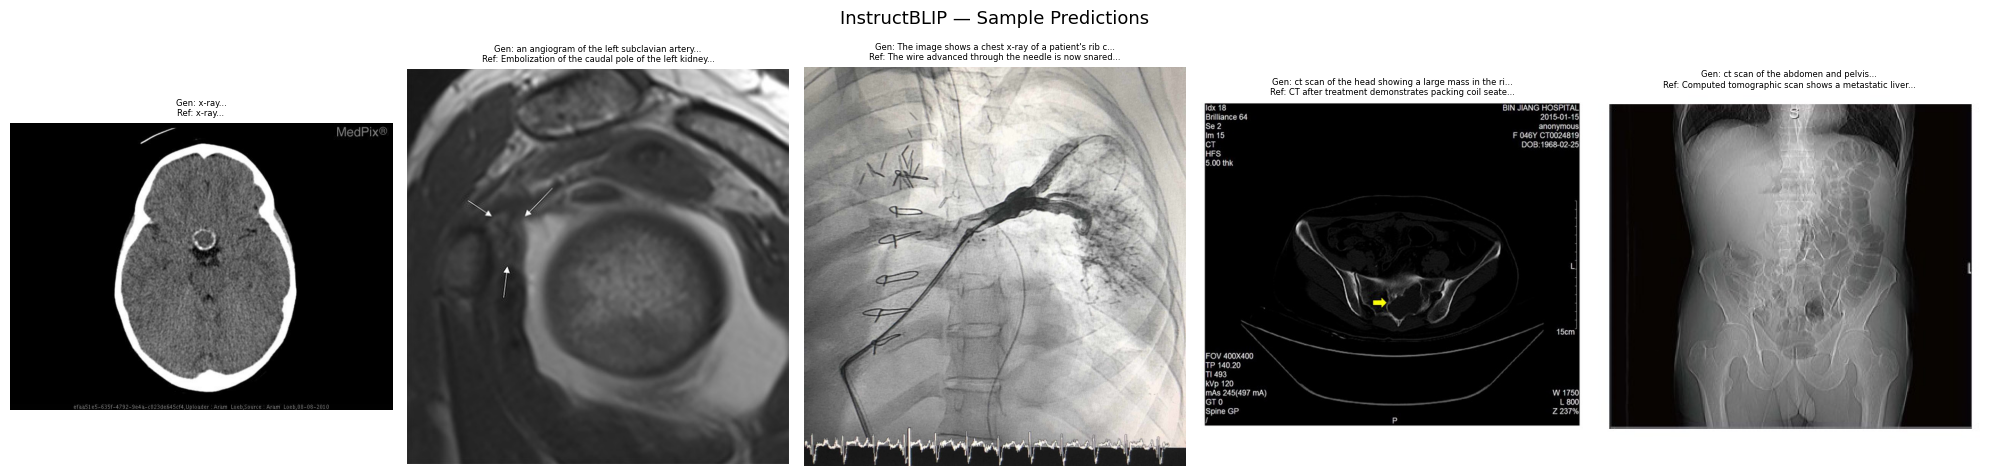

Sample predictions saved to ./results\instructblip_sample_predictions.png


In [19]:
sample_df   = val_roco.sample(5, random_state=RANDOM_STATE).reset_index(drop=True)
sample_idxs = sample_df.index.tolist()

sample_preds = [instructblip_preds[i] for i in sample_idxs]
sample_refs  = [instructblip_refs[i]  for i in sample_idxs]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(f'InstructBLIP — Sample Predictions', fontsize=13)

for i, ax in enumerate(axes):
    img = open_image_from_dataset_value(sample_df.iloc[i]['image'])
    ax.imshow(img.convert('RGB'))
    ax.axis('off')
    title = f"Gen: {sample_preds[i][:50]}...\nRef: {sample_refs[i][:50]}..."
    ax.set_title(title, fontsize=6, wrap=True)

plt.tight_layout()
fig_path = os.path.join(SAVE_DIR, 'instructblip_sample_predictions.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sample predictions saved to {fig_path}')

In [20]:
print('\n=== InstructBLIP Sample Predictions vs References ===\n')
for i, (pred, ref) in enumerate(zip(sample_preds, sample_refs)):
    print(f'--- Sample {i+1} ---')
    print(f'Question:  {sample_df.iloc[i]["question"]}')
    print(f'Generated: {pred}')
    print(f'Reference: {ref}')
    print()


=== InstructBLIP Sample Predictions vs References ===

--- Sample 1 ---
Question:  where is the mass located?
Generated: x-ray
Reference: x-ray

--- Sample 2 ---
Question:  Describe the medical findings in this image.
Generated: an angiogram of the left subclavian artery
Reference: Embolization of the caudal pole of the left kidney. Perfusion of blood vessels in the cranial pole of the left kidney is visualized using contrast angiography.

--- Sample 3 ---
Question:  Describe the medical findings in this image.
Generated: The image shows a chest x-ray of a patient's rib cage, with an arrow pointing to the right side of the chest. The arrow is likely pointing to an area of interest or concern for the radiologist or medical professional interpreting the image.
Reference: The wire advanced through the needle is now snared by a goose neck snare placed using the left internal jugular vein approach. 190 × 190 mm (137 × 137 DPI)

--- Sample 4 ---
Question:  Describe the medical findings in t

## 13. Save All Predictions

In [ ]:
final_df = pd.DataFrame({
    'question':        val_roco['question'].tolist(),
    'reference':       instructblip_refs,
    'instructblip':    instructblip_preds,
})

pred_path = os.path.join(SAVE_DIR, 'instructblip_all_predictions.csv')
final_df.to_csv(pred_path, index=False)
print(f'All predictions saved to {pred_path}')